#Workshop 2 : Report on Subject Specific Big Data Process

##Topic: Water Quality Analysis and Potability Prediction

### Data Exploration / Understanding / Transformation / Model Training

1. Import Required Libraries

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Dataset

In [176]:
df = pd.read_csv("/content/drive/MyDrive/6CS030 - Big Data/Workshop2/water_potability.csv")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape of dataset: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


3. Data Understanding

In [177]:
print("First 5 rows of the dataset:")
display(df.head())

print("\nLast 5 rows of the dataset:")
display(df.tail())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe())

First 5 rows of the dataset:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



Last 5 rows of the dataset:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1



Shape of dataset:
(3276, 10)

Column names:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

Summary statistics:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


4. Checking Missing Values and Duplicate Records

In [178]:
print("Missing values in each column:")
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ['Column', 'Missing Values']
display(missing_values)

print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:


,Column,Missing Values
0,ph,491
1,Hardness,0
2,Solids,0
3,Chloramines,0
4,Sulfate,781
5,Conductivity,0
6,Organic_carbon,0
7,Trihalomethanes,162
8,Turbidity,0
9,Potability,0



Total missing values in the dataset:
1434

Number of duplicate rows:
0


5. Checking Target Variable Distribution

Value counts of Potability:


,count
Potability,
0,1998
1,1278


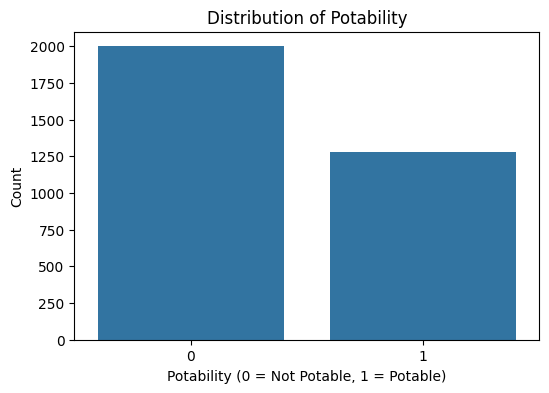

In [179]:
print("Value counts of Potability:")
display(df['Potability'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Potability')
plt.title("Distribution of Potability")
plt.xlabel("Potability (0 = Not Potable, 1 = Potable)")
plt.ylabel("Count")
plt.show()

6. Handling Missing Values

In [180]:
# Create a clean copy
df_clean = df.copy()

# Fill missing values using median
df_clean['ph'] = df_clean['ph'].fillna(df_clean['ph'].median())
df_clean['Sulfate'] = df_clean['Sulfate'].fillna(df_clean['Sulfate'].median())
df_clean['Trihalomethanes'] = df_clean['Trihalomethanes'].fillna(df_clean['Trihalomethanes'].median())

print("Missing values after handling:")
missing_after = df_clean.isnull().sum().reset_index()
missing_after.columns = ['Column', 'Missing Values After Cleaning']
display(missing_after)

Missing values after handling:


,Column,Missing Values After Cleaning
0,ph,0
1,Hardness,0
2,Solids,0
3,Chloramines,0
4,Sulfate,0
5,Conductivity,0
6,Organic_carbon,0
7,Trihalomethanes,0
8,Turbidity,0
9,Potability,0


 7. Data Transformation

In [181]:
# Create pH category
df_clean['ph_category'] = pd.cut(
    df_clean['ph'],
    bins=[0, 6.5, 8.5, 14],
    labels=['Acidic', 'Neutral', 'Alkaline']
)

# Create hardness category
df_clean['hardness_category'] = pd.qcut(
    df_clean['Hardness'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Create solids category
df_clean['solids_category'] = pd.qcut(
    df_clean['Solids'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("Data transformation completed successfully.")
display(df_clean[['ph', 'ph_category', 'Hardness', 'hardness_category', 'Solids', 'solids_category']].head())

Data transformation completed successfully.


,ph,ph_category,Hardness,hardness_category,Solids,solids_category
0,7.036752,Neutral,204.890455,Medium,20791.318981,Medium
1,3.716080,Acidic,129.422921,Low,18630.057858,Medium
2,8.099124,Neutral,224.236259,High,19909.541732,Medium
3,8.316766,Neutral,214.373394,High,22018.417441,Medium
4,9.092223,Alkaline,181.101509,Low,17978.986339,Medium


8. Exploratory Data Analysis (EDA)

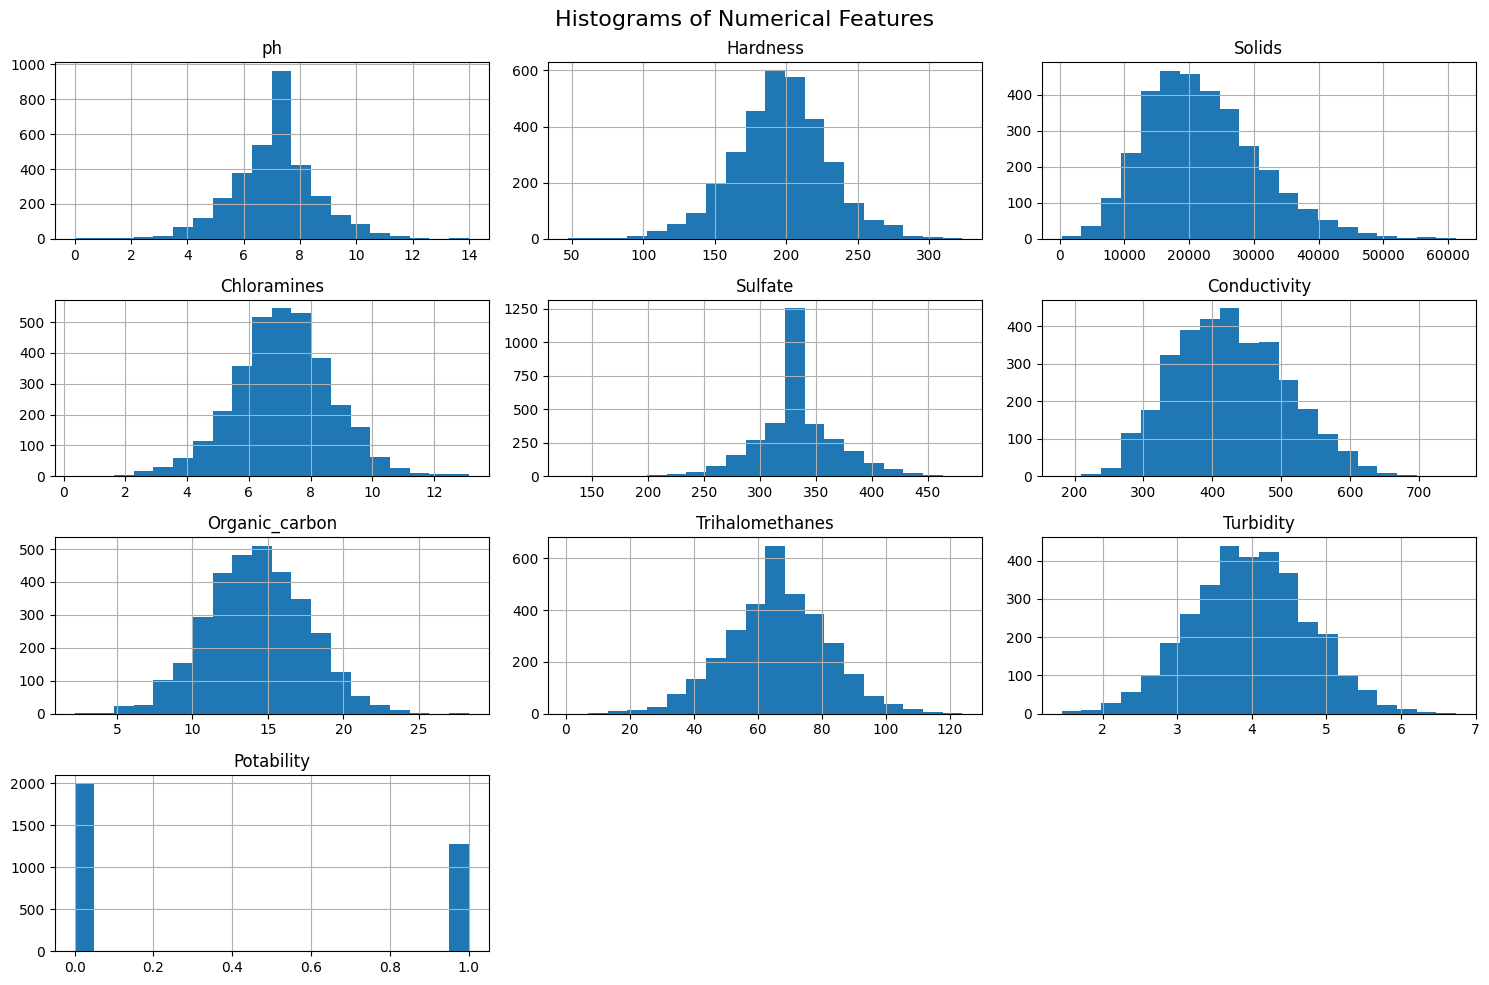

In [182]:
# 8.1 Histograms of numerical features

df_clean.hist(figsize=(15,10), bins=20)
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

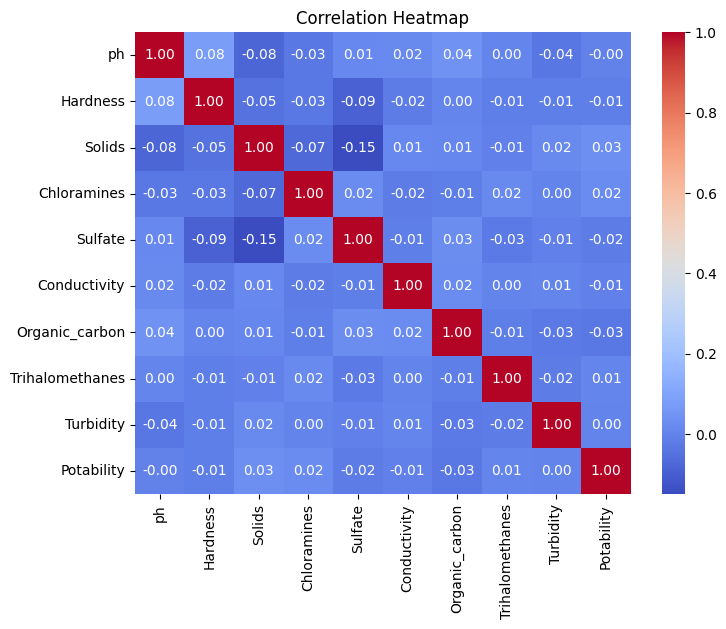

In [183]:
# 8.2 Correlation heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

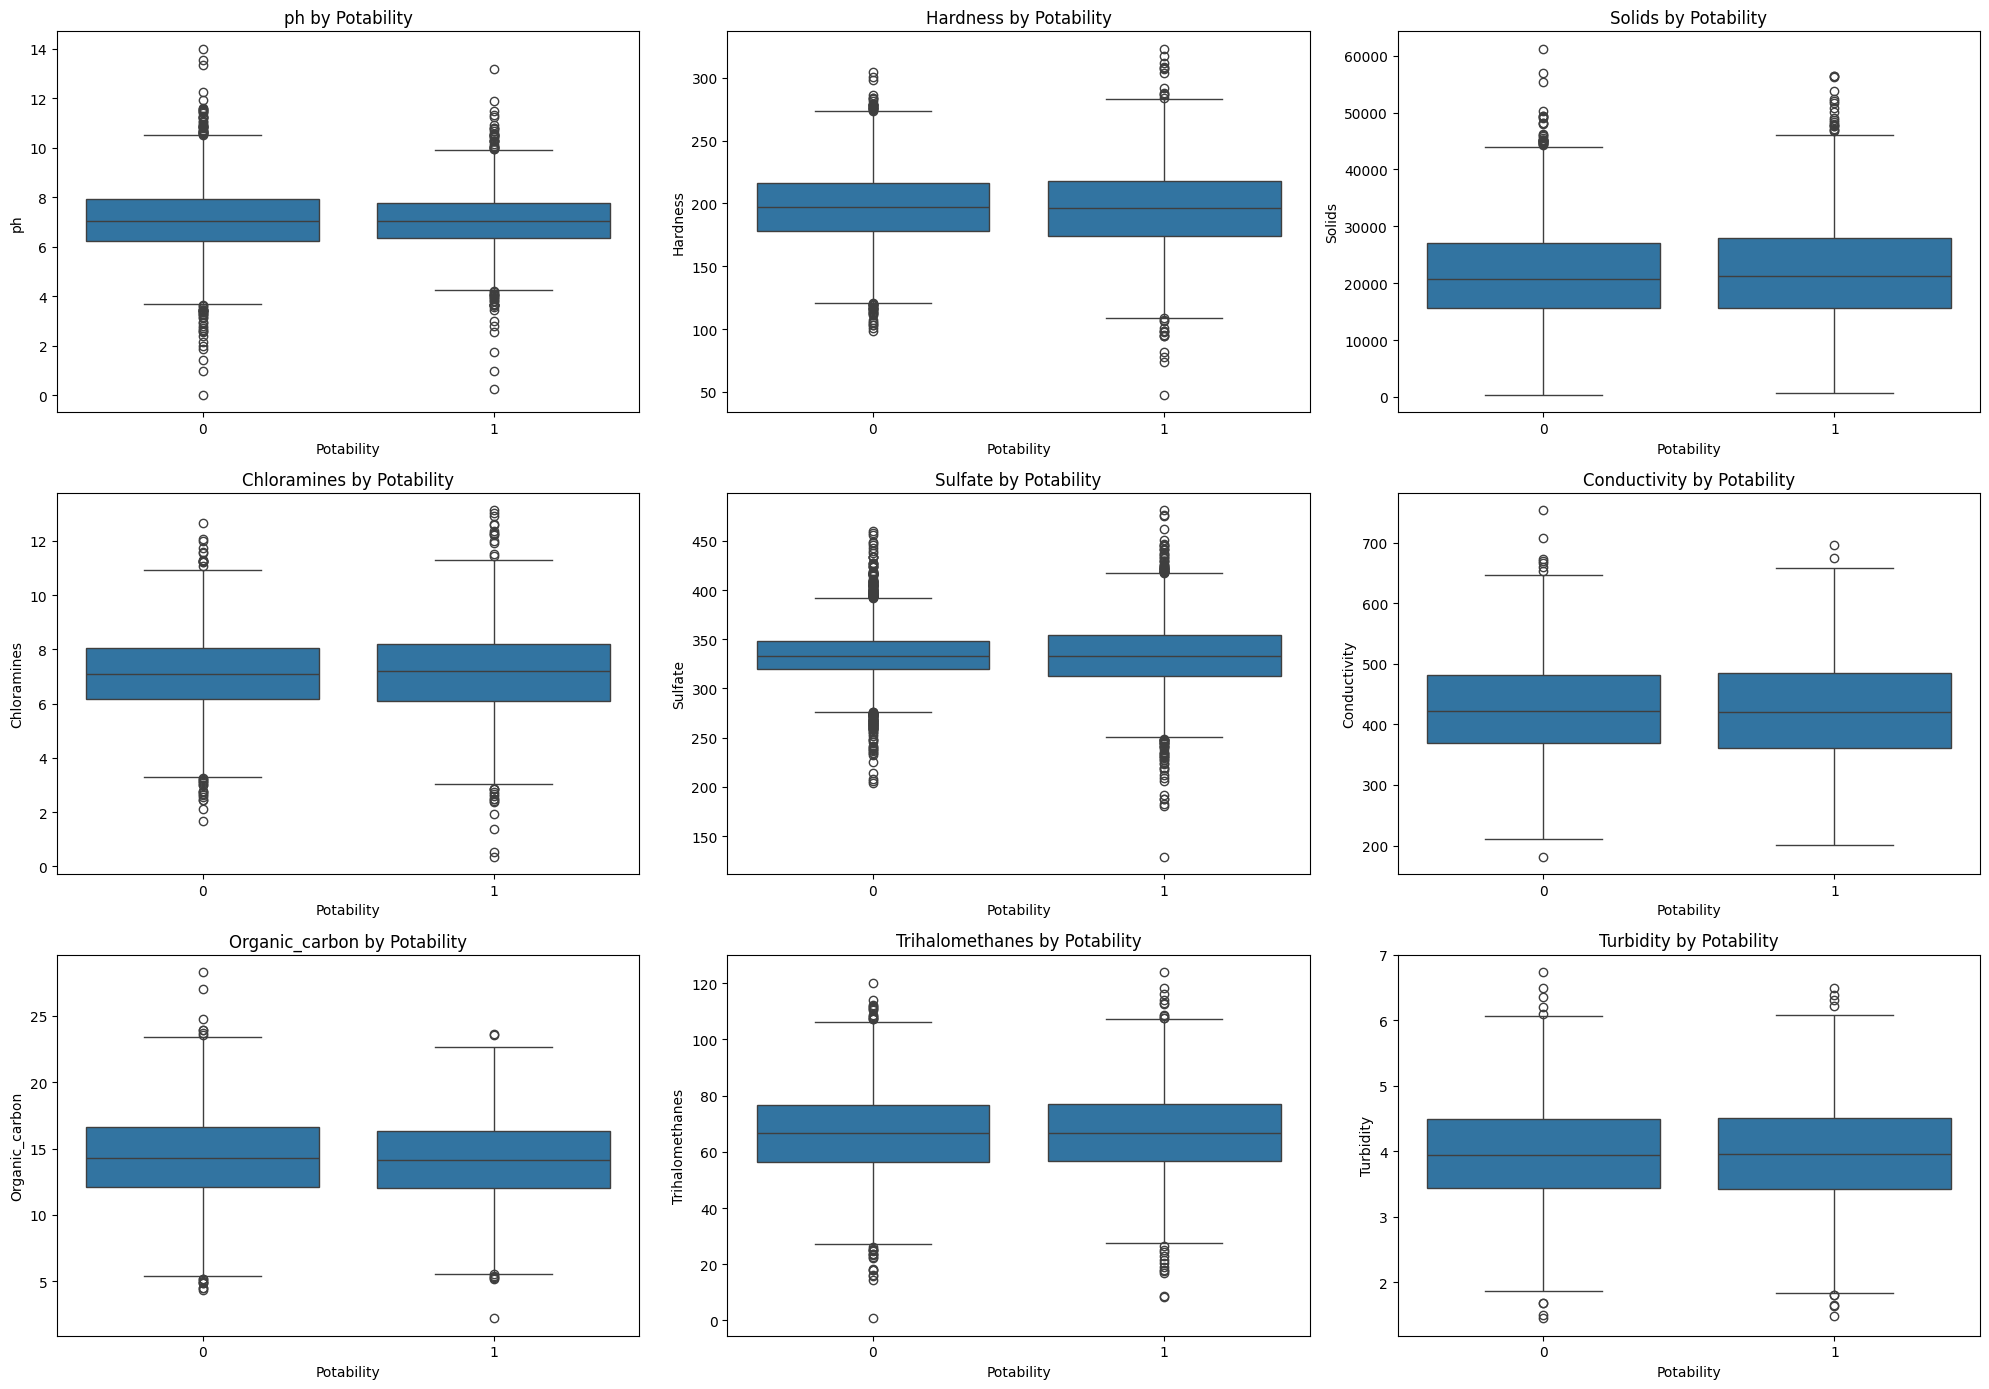

In [184]:
# 8.3 Boxplots of numerical features by Potability

numeric_cols = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_clean, x='Potability', y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Potability")
    axes[i].set_xlabel("Potability")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

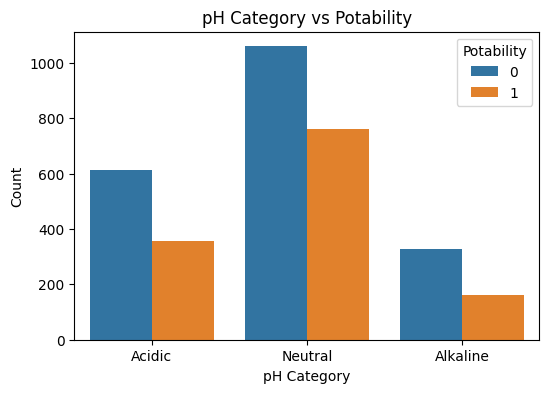

In [185]:
# 8.4 pH category vs Potability

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='ph_category', hue='Potability')
plt.title("pH Category vs Potability")
plt.xlabel("pH Category")
plt.ylabel("Count")
plt.show()

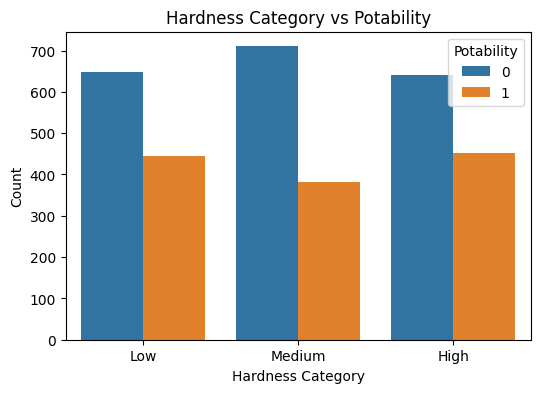

In [186]:
# 8.5 Hardness category vs Potability

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='hardness_category', hue='Potability')
plt.title("Hardness Category vs Potability")
plt.xlabel("Hardness Category")
plt.ylabel("Count")
plt.show()

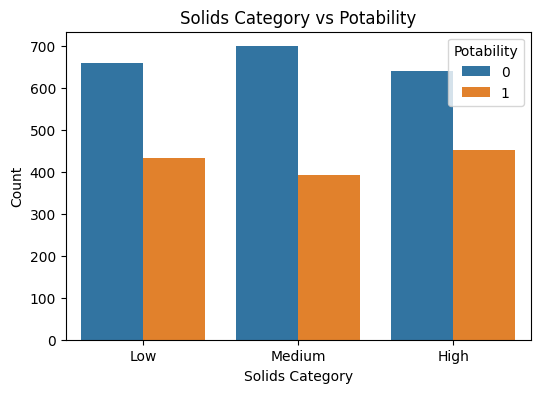

In [187]:
# 8.6 Solids category vs Potability

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='solids_category', hue='Potability')
plt.title("Solids Category vs Potability")
plt.xlabel("Solids Category")
plt.ylabel("Count")
plt.show()

9. Insight-Oriented Analysis

In [188]:
# 9.1 Mean feature values by Potability

mean_by_potability = df_clean.groupby('Potability').mean(numeric_only=True)
print("Mean values of features grouped by Potability:")
display(mean_by_potability)

Mean values of features grouped by Potability:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
Potability,,,,,,,,,
0,7.077736,196.733292,21777.490788,7.092175,334.200184,426.730454,14.364335,66.320635,3.965800
1,7.068655,195.800744,22383.991018,7.169338,332.683125,425.383800,14.160893,66.543247,3.968328


In [189]:
# 9.2 Potability rate by pH category

print("Potability rate by pH category:")
potability_by_ph = df_clean.groupby('ph_category', observed=False)['Potability'].mean().reset_index()
display(potability_by_ph)

Potability rate by pH category:


,ph_category,Potability
0,Acidic,0.368149
1,Neutral,0.417812
2,Alkaline,0.331288


In [190]:
# 9.3 Potability rate by hardness category

potability_by_hardness = df_clean.groupby('hardness_category', observed=False)['Potability'].mean().reset_index()
print("Potability rate by hardness category:")
display(potability_by_hardness)

Potability rate by hardness category:


,hardness_category,Potability
0,Low,0.407509
1,Medium,0.349817
2,High,0.413004


In [191]:
# 9.4 Potability rate by solids category

potability_by_solids = df_clean.groupby('solids_category', observed=False)['Potability'].mean().reset_index()
print("Potability rate by solids category:")
display(potability_by_solids)

Potability rate by solids category:


,solids_category,Potability
0,Low,0.396520
1,Medium,0.359890
2,High,0.413919


10. Model Training for Potability Prediction

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Accuracy Score: 0.6737804878048781

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656



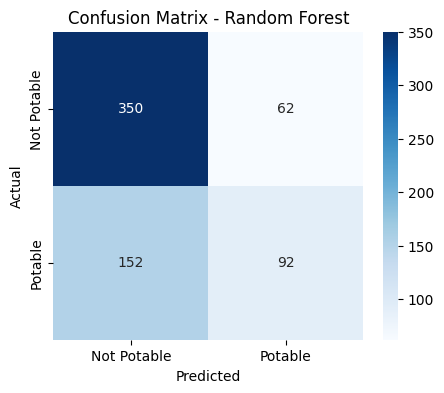

In [193]:
# Features and target
X = df_clean.drop(columns=['Potability', 'ph_category', 'hardness_category', 'solids_category'])
y = df_clean['Potability']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model evaluation
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


11. Feature Importance

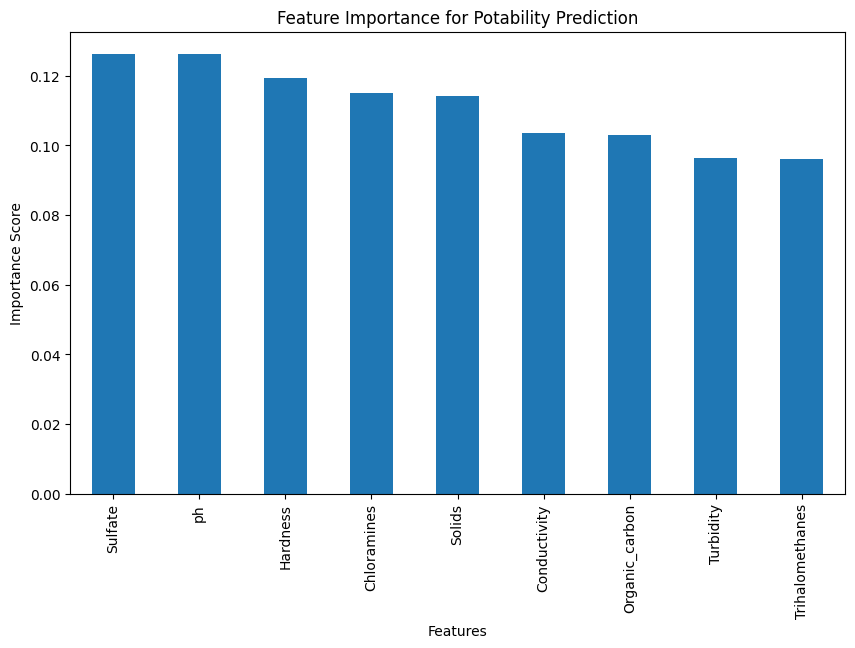

Feature importance values:


,0
Sulfate,0.126330
ph,0.126106
Hardness,0.119346
Chloramines,0.115096
Solids,0.114246
Conductivity,0.103434
Organic_carbon,0.102947
Turbidity,0.096463
Trihalomethanes,0.096031


In [194]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance for Potability Prediction")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.show()

print("Feature importance values:")
display(feature_importance)
